# Bayes估计与先验

## Goal
八条合成二元数据、三次成功。在明确Beta(2,2)先验后，先手算后验Beta(5,7)，再用积分、精确分数与有限模拟核验。完整定义与推导见lecture.pdf，独立步骤见lab.pdf，18题详解见answers.pdf。

保留运行中，20000批共享参数预测的成功数方差约1.185623，逐次重抽参数的方差约0.975626；对应理论分别为140/117与35/36。它们是两个不同层次模型，有限频率不能证明模型符合现实。

## Setup
请在本单元目录中打开Notebook。这里只读取随附合成CSV，不需要网络、账户或GPU。首格锁定固定图题对应的八条观察与五种先验。若改变数据，请另存CSV用脚本参数运行，同时重新计算理论值和图题。

### Key Assumptions
每一批未来结果共用同一个未知θ，给定θ条件独立；旧数据与新结果在给定θ后独立。先验是明确的教学选择，不是客观真相。数值范围比数学定义更窄，超界会报错。

In [1]:
import sys, math, io
from fractions import Fraction
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
import experiment as e
plt.rcParams.update({"font.size":11,"axes.spines.top":False,"axes.spines.right":False,"figure.facecolor":"white"})
def show(fig):
    fig.tight_layout(pad=1.5)
    buffer=io.BytesIO(); fig.savefig(buffer,format="png",dpi=130,bbox_inches="tight")
    plt.close(fig); display(Image(data=buffer.getvalue()))
rows=e.load_observations(); priors=e.load_priors()
e.require(rows==[{"observation_id":f"O{i+1:02d}","batch":"first" if i<4 else "second","success":v} for i,v in enumerate([0,0,1,0,1,0,1,0])],"Fixed notebook baseline changed; use script with alternate CSV and recompute labels.")
e.require([(r["prior_id"],r["alpha"],r["beta"]) for r in priors]==[("uniform",1,1),("main",2,2),("strong",20,20),("low_center",2,8),("boundary",.5,.5)],"Fixed prior baseline changed.")
print({"Python":sys.version.split()[0],"NumPy":np.__version__,"Matplotlib":matplotlib.__version__,"RNG":"PCG64"})
print("observations:",rows)

{'Python': '3.12.14', 'NumPy': '2.3.5', 'Matplotlib': '3.10.8', 'RNG': 'PCG64'}
observations: [{'observation_id': 'O01', 'batch': 'first', 'success': 0}, {'observation_id': 'O02', 'batch': 'first', 'success': 0}, {'observation_id': 'O03', 'batch': 'first', 'success': 1}, {'observation_id': 'O04', 'batch': 'first', 'success': 0}, {'observation_id': 'O05', 'batch': 'second', 'success': 1}, {'observation_id': 'O06', 'batch': 'second', 'success': 0}, {'observation_id': 'O07', 'batch': 'second', 'success': 1}, {'observation_id': 'O08', 'batch': 'second', 'success': 0}]


## Steps
### 1. 从八条记录到后验
唯一ID防显式重复；数值相同不说明来自同一次测量。第一批一次成功，第二批两次。

In [2]:
print("Sequential:",e.sequential_update(2,2,rows))
a,b=e.posterior(2,2,8,3)
print("One combined update:",(a,b))
print("Incorrect reuse of all eight:",e.posterior(a,b,8,3))
print("No observations:",e.posterior(2,2,0,0))

Sequential: [{'batch': 'first', 'a': 3.0, 'b': 5.0}, {'batch': 'second', 'a': 5.0, 'b': 7.0}]
One combined update: (5.0, 7.0)
Incorrect reuse of all eight: (8.0, 12.0)
No observations: (2.0, 2.0)


### 2. 精确分母与参数事件
有序事件与计数事件证据相差56倍，后验相同。参数超过1/2不是下一次成功。

In [3]:
B0=e.beta_fraction(2,2); B1=e.beta_fraction(5,7)
print("B(2,2), B(5,7):",B0,B1)
print("Ordered evidence:",B1/B0,"count evidence:",56*B1/B0)
print(e.evidence(2,2,8,3)); print(e.evidence(2,2,8,3,True))
print("Posterior P(theta > .5):",e.beta_integer_interval(5,7,Fraction(1,2),Fraction(1)))
print("Posterior moments:",e.beta_moments(a,b))

B(2,2), B(5,7): 1/6 1/2310
Ordered evidence: 1/385 count evidence: 8/55
{'log_evidence': -5.953243334287785, 'evidence': 0.0025974025974025965, 'data_event': 'ordered_sequence'}
{'log_evidence': -1.927891643552635, 'evidence': 0.14545454545454545, 'data_event': 'count'}
Posterior P(theta > .5): 281/1024
Posterior moments: {'mean': 0.4166666666666667, 'second_moment': 0.19230769230769232, 'variance': 0.0186965811965812}


### 3. 先验、似然、后验分开纵轴
未归一化乘积的面积为证据1/385。曲线的峰高都不是一个参数点的概率。

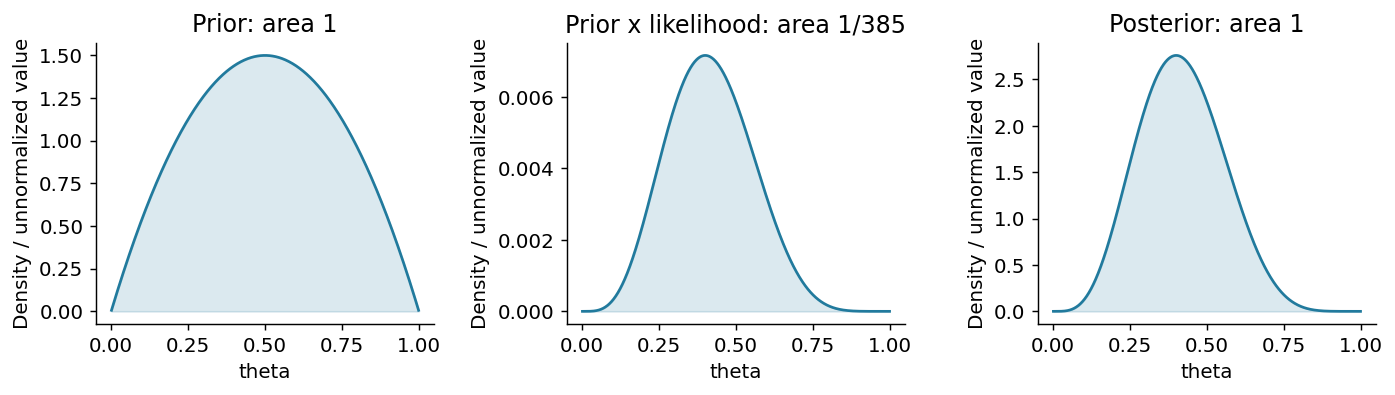

In [4]:
grid=np.linspace(.001,.999,700)
prior=np.array([e.beta_pdf(float(t),2,2) for t in grid])
post=np.array([e.beta_pdf(float(t),a,b) for t in grid])
likelihood=grid**3*(1-grid)**5
fig,axes=plt.subplots(1,3,figsize=(11,3.3))
for ax,y,label in zip(axes,[prior,likelihood*prior,post],["Prior: area 1","Prior x likelihood: area 1/385","Posterior: area 1"]):
    ax.plot(grid,y,color="#217a9d"); ax.fill_between(grid,y,alpha=.16,color="#217a9d")
    ax.set(title=label,xlabel="theta",ylabel="Density / unnormalized value")
show(fig)

### 4. 面积检查与奇异边界
用中点求积而不是忘记格宽的密度求和。避开端点不代表奇异性误差已消失。

n      smooth posterior area       singular prior area
20 0.9999991764163549 0.9141100099717774
100 0.9999999999467424 0.9615103769230495
1000 1.0000000000000009 0.9878229841674374
Arcsine substitution, exact transformed integral: 1.0
Endpoint limits: beta_pdf(0,2,2), beta_pdf(0,1,3), beta_pdf(0,.5,.5):
0.0 3.000000000000002 inf


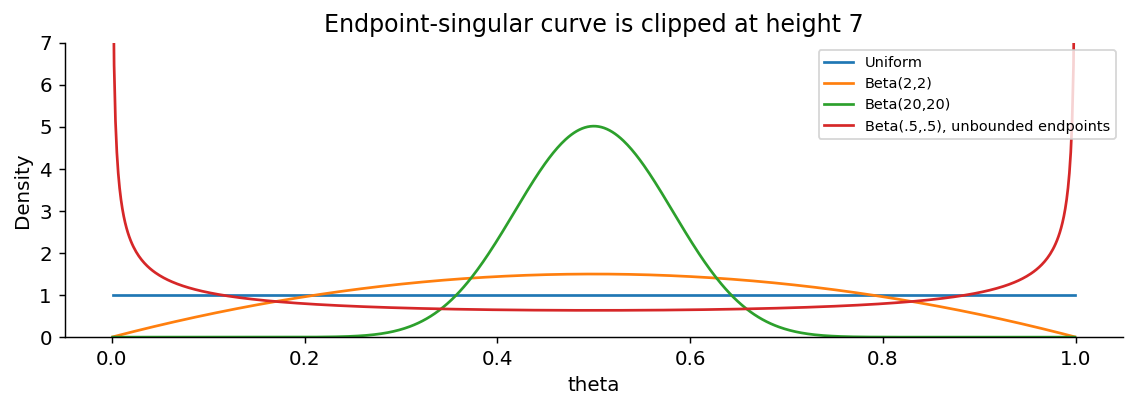

In [5]:
print("n      smooth posterior area       singular prior area")
for n in [20,100,1000]:
    print(n,e.quadrature(5,7,n),e.quadrature(.5,.5,n))
print("Arcsine substitution, exact transformed integral:",(2/math.pi)*(math.pi/2))
print("Endpoint limits: beta_pdf(0,2,2), beta_pdf(0,1,3), beta_pdf(0,.5,.5):")
print(e.beta_pdf(0,2,2),e.beta_pdf(0,1,3),e.beta_pdf(0,.5,.5))
fig,ax=plt.subplots(figsize=(9,3.4))
for aa,bb,label in [(1,1,"Uniform"),(2,2,"Beta(2,2)"),(20,20,"Beta(20,20)"),(.5,.5,"Beta(.5,.5), unbounded endpoints")]:
    ax.plot(grid,[e.beta_pdf(float(t),aa,bb) for t in grid],label=label)
ax.set(xlabel="theta",ylabel="Density",ylim=(0,7),title="Endpoint-singular curve is clipped at height 7")
ax.legend(fontsize=8);show(fig)

### 5. 三个点估计与平方风险
风险曲线是理论后验期望，未通过有限随机样本拟合。

MLE: 0.375 theta-coordinate MAP: {'kind': 'unique_interior', 'theta': 0.4} posterior mean: 0.4166666666666667
Risk at mean / MAP / MLE: [0.0186965811965812, 0.018974358974358976, 0.02043269230769231]


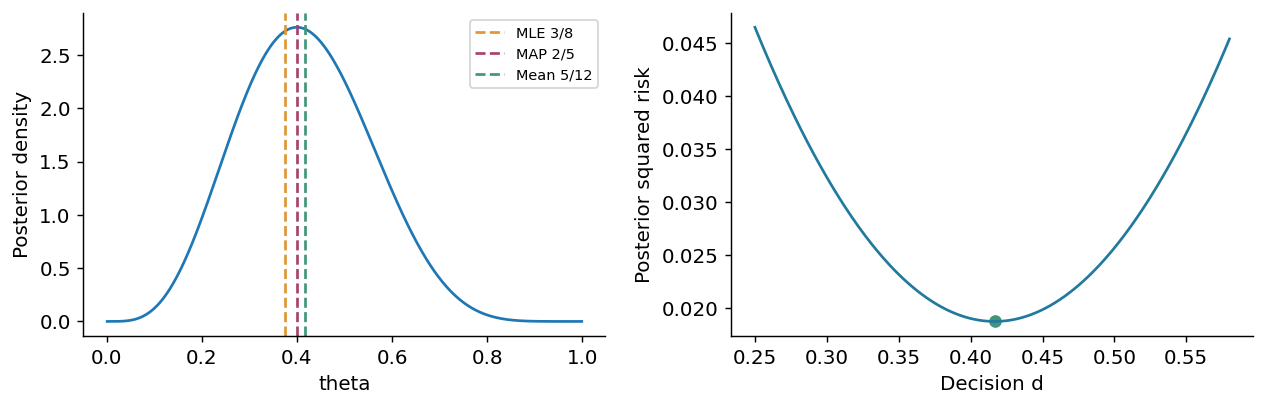

In [6]:
mom=e.beta_moments(a,b);q,v=mom["mean"],mom["variance"]
print("MLE:",3/8,"theta-coordinate MAP:",e.beta_mode(a,b),"posterior mean:",q)
print("Risk at mean / MAP / MLE:",[v+(d-q)**2 for d in [q,.4,.375]])
fig,axes=plt.subplots(1,2,figsize=(10,3.4));axes[0].plot(grid,post)
for d,label,col in [(.375,"MLE 3/8","#df9633"),(.4,"MAP 2/5","#a8426e"),(q,"Mean 5/12","#42957c")]:
    axes[0].axvline(d,color=col,ls="--",label=label)
axes[0].set(xlabel="theta",ylabel="Posterior density");axes[0].legend(fontsize=8)
d=np.linspace(.25,.58,300);axes[1].plot(d,v+(d-q)**2,color="#217a9d");axes[1].scatter([q],[v],color="#42957c")
axes[1].set(xlabel="Decision d",ylabel="Posterior squared risk")
show(fig)

### 6. 边界众数与换坐标
None附带明确的kind，表示没有唯一有限内部密度峰。η坐标密度需要Jacobian。

(1, 1) {'kind': 'uniform_nonunique', 'theta': None}
(1, 3) {'kind': 'continuous_closure_endpoint', 'theta': 0.0}
(0.5, 2) {'kind': 'left_boundary_unbounded', 'theta': None}
(0.5, 0.5) {'kind': 'both_boundaries_unbounded', 'theta': None}
Eta-coordinate mode mapped to theta: 0.4166666666666667
Actual eta mode: -0.3364722366212129


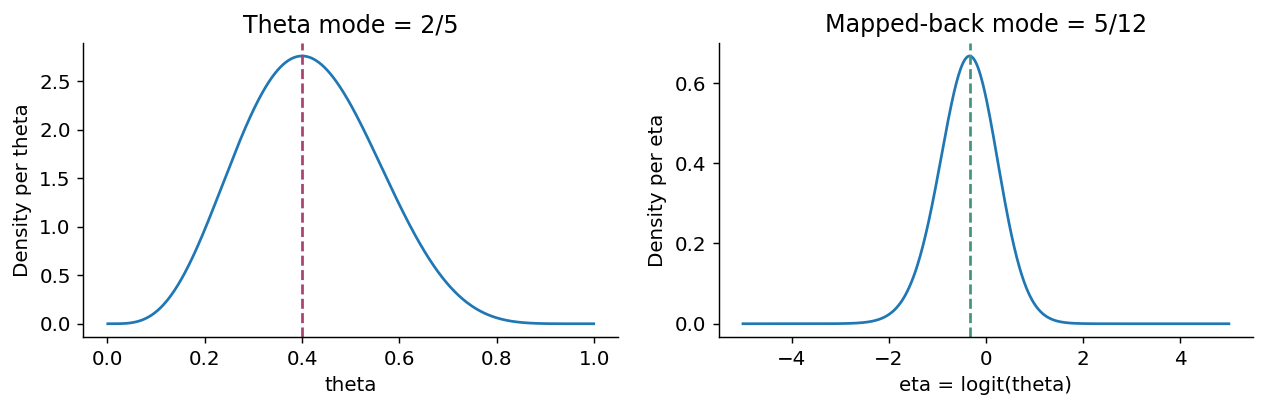

In [7]:
for aa,bb in [(1,1),(1,3),(.5,2),(.5,.5)]:
    print((aa,bb),e.beta_mode(aa,bb))
eta=np.linspace(-5,5,700);theta=1/(1+np.exp(-eta))
eta_density=np.array([e.beta_pdf(float(t),a,b)*t*(1-t) for t in theta])
print("Eta-coordinate mode mapped to theta:",a/(a+b))
print("Actual eta mode:",math.log(a/b))
fig,axes=plt.subplots(1,2,figsize=(10,3.4));axes[0].plot(grid,post);axes[0].axvline(.4,color="#a8426e",ls="--");axes[0].set(xlabel="theta",ylabel="Density per theta",title="Theta mode = 2/5")
axes[1].plot(eta,eta_density);axes[1].axvline(math.log(a/b),color="#42957c",ls="--");axes[1].set(xlabel="eta = logit(theta)",ylabel="Density per eta",title="Mapped-back mode = 5/12")
show(fig)

### 7. 未来事件的完整积分
先写给定θ时的事件概率，再取后验期望。有限质量列表能直接核对归一化与矩。

In [8]:
exact=e.exact_predictive(5,7,4)
mean=sum((j*p for j,p in enumerate(exact)),Fraction(0))
var=sum(((j-mean)**2*p for j,p in enumerate(exact)),Fraction(0))
print("Exact future masses:",[str(p) for p in exact],"sum:",sum(exact))
print("Exact predictive mean / variance:",mean,var)
print("Two successes:",Fraction(5,26),"plug-in:",Fraction(25,144),"difference:",Fraction(35,1872))
print(e.predictive_moments(5,7,4))
print("J=2 probability: full",exact[2],"plugin",Fraction(1225,3456))

Exact future masses: ['2/13', '4/13', '4/13', '7/39', '2/39'] sum: 1
Exact predictive mean / variance: 5/3 140/117
Two successes: 5/26 plug-in: 25/144 difference: 35/1872
{'mean': 1.6666666666666667, 'variance': 1.1965811965811965, 'plugin_variance': 0.9722222222222221, 'pair_covariance': 0.0186965811965812, 'pair_correlation': 0.07692307692307693}
J=2 probability: full 4/13 plugin 1225/3456


### 8. 一个共同参数与四个独立参数
共享数组θ形状(R,)，反例θ形状(R,4)。下面每一条频率都分母为全部R，不截掉极端结果。

Parameter draws: {'mean': 0.4171229174687145, 'variance': 0.018997095958645766}


Shared parameter counts: {'mean': 1.67285, 'variance': 1.1856228775}
Redrawn parameter counts: {'mean': 1.66545, 'variance': 0.9756262975}


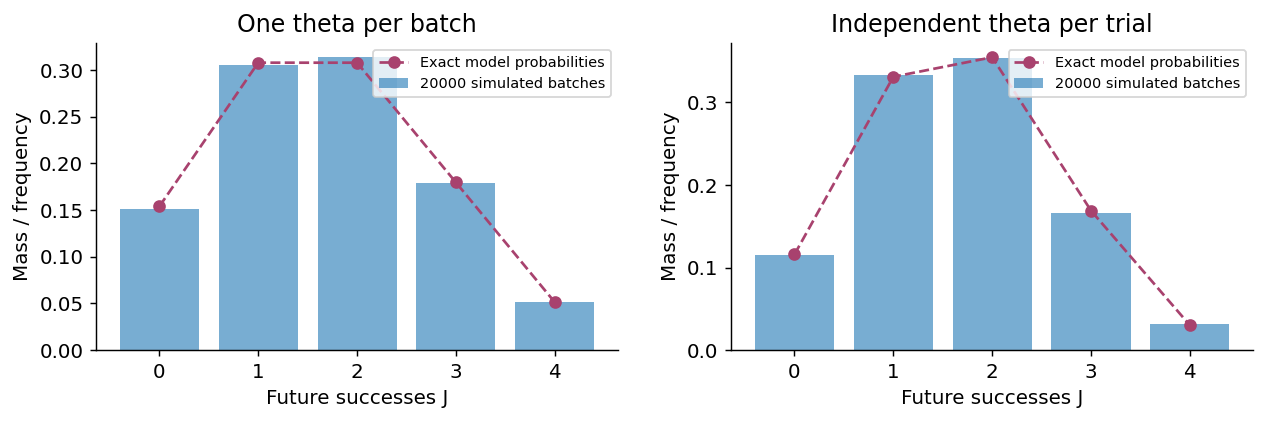

In [9]:
sim=e.simulate(a,b,m=4,repetitions=20000,seed=24024)
print("Parameter draws:",e.population_moments(sim["theta"]))
print("Shared parameter counts:",e.population_moments(sim["shared_counts"]))
print("Redrawn parameter counts:",e.population_moments(sim["redrawn_counts"]))
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
for ax,key,ref,title in [(axes[0],"shared_counts",e.predictive_pmf(a,b,4),"One theta per batch"),(axes[1],"redrawn_counts",e.plugin_pmf(4,q),"Independent theta per trial")]:
    frequency=np.bincount(sim[key],minlength=5)/20000
    ax.bar(range(5),frequency,alpha=.6,label="20000 simulated batches")
    ax.plot(range(5),ref,"o--",color="#a8426e",label="Exact model probabilities")
    ax.set(xlabel="Future successes J",ylabel="Mass / frequency",title=title,xticks=range(5));ax.legend(fontsize=8)
show(fig)

### 9. 固定成功比例的先验敏感性
这张图只改变公式输入，不采新随机数据，所以不提供覆盖率。

Beta(1,1) [0.4, 0.38095238095238093, 0.37623762376237624]
Beta(2,2) [0.4166666666666667, 0.38636363636363635, 0.37745098039215685]
Beta(20,20) [0.4791666666666667, 0.4375, 0.3958333333333333]
Beta(2,8) [0.2777777777777778, 0.34, 0.36666666666666664]


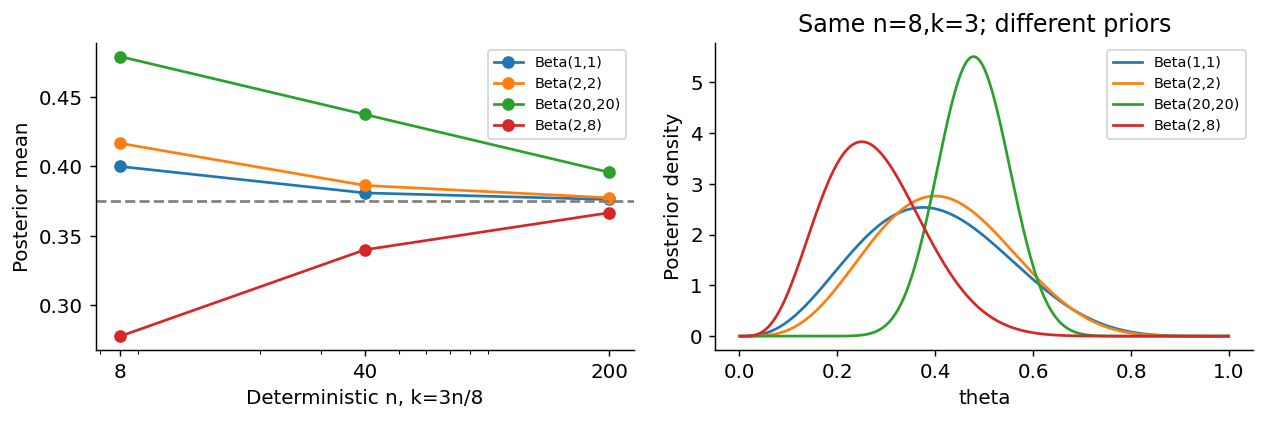

In [10]:
fig,axes=plt.subplots(1,2,figsize=(10,3.5));ns=[8,40,200]
for aa,bb,label in [(1,1,"Beta(1,1)"),(2,2,"Beta(2,2)"),(20,20,"Beta(20,20)"),(2,8,"Beta(2,8)")]:
    means=[e.beta_moments(*e.posterior(aa,bb,n,3*n//8))["mean"] for n in ns]
    print(label,means)
    axes[0].plot(ns,means,"o-",label=label)
    ap,bp=e.posterior(aa,bb,8,3)
    axes[1].plot(grid,[e.beta_pdf(float(t),ap,bp) for t in grid],label=label)
axes[0].axhline(.375,color="gray",ls="--");axes[0].set(xscale="log",xticks=ns,xticklabels=ns,xlabel="Deterministic n, k=3n/8",ylabel="Posterior mean")
axes[1].set(xlabel="theta",ylabel="Posterior density",title="Same n=8,k=3; different priors")
for ax in axes:ax.legend(fontsize=8)
show(fig)

## Checks
### 10. 不可能的数据不能强行归一化
只在0和1放先验质量的模型排除了混合数据。记录报错原因，而不是把分母替换成小数。

In [11]:
for name,fn in [("zero evidence",lambda:e.discrete_update([0,1],[.5,.5],8,3)),("duplicate observation",lambda:e.validate_observations(rows+[rows[-1]])),("improper prior",lambda:e.posterior(0,0,8,3)),("bool prior",lambda:e.posterior(True,2,8,3))]:
    try:
        fn()
    except ValueError as error:
        print(name,"->",str(error))
    else:
        raise RuntimeError("Expected failure was not detected")
print("Reference checks:",e.reference_checks())
print("Boundary checks:",e.boundary_checks())

zero evidence -> zero evidence or unsupported positive underflow
duplicate observation -> duplicate observation ID
improper prior -> numerical implementation requires a,b >= 0.25; theory allows all positive shapes
bool prior -> a must be an ordinary Python/NumPy real scalar, not bool/text/complex/Fraction
Reference checks: 1405
Boundary checks: {'expected_rejections': 55, 'accepted_groups': 17}


### 11. 把脚本结果与Notebook对接
完整报告保留理论值与有限模拟值，JSON不允许NaN。这里只在内存计算，不隐式覆盖自己的结果目录。

In [12]:
report=e.run()
print("Report counts:",report["n"],report["k"])
print("Predictive mass sum:",report["predictive_mass_sum"])
print("Grid checks:",report["grid_midpoint"])
print("Constant after complete validation:",e.population_moments([.1]*7))
e.require(report["posterior"]==[5.0,7.0],"Report baseline mismatch")
e.require(np.array_equal(sim["shared_counts"],e.simulate(a,b)["shared_counts"]),"Fixed-stream mismatch in this environment")
print("All checks passed in this sequential execution.")

Report counts: 8 3
Predictive mass sum: 1.0000000000000022
Grid checks: [{'n': 20, 'integral': 0.9999991764163549}, {'n': 100, 'integral': 0.9999999999467424}, {'n': 1000, 'integral': 1.0000000000000009}]
Constant after complete validation: {'mean': 0.1, 'variance': 0.0}
All checks passed in this sequential execution.


## Next Steps
写出一个后验参数事件、一个未来结果事件和一个错误重复证据案例。解释先验强度、模型支持与重采样层次各自影响什么。第二十五讲讨论区间、重复抽样覆盖率和Bootstrap；这里的有限预测频率不是置信区间覆盖率。

保留运行仅验证当前Python/NumPy环境中的离线代码与真实InProcessKernel顺序执行。浏览器UI、普通socket内核传输、读者Anaconda安装和跨版本逐位随机流没有测试。